## Create Csv file with Elo Ratings for Coaches and Teams
Season, DayNum, TeamID, (CoachElo, TeamElo) (until DayNum.Season)
Save to data/elo.csv

# Teoria rankingu Elo

System Elo opiera się na modelu probabilistycznym, który zakłada, że wyniki rywalizacji można modelować za pomocą funkcji logistycznej.

Prawdopodobieństwo, że drużyna A (z rankingiem Elo $R_A$) pokona drużynę B (z rankingiem Elo $R_B$) jest dane wzorem:

$$
P(A) = \frac{1}{1 + 10^{\frac{R_B - R_A}{400}}}
$$

Analogicznie, prawdopodobieństwo, że drużyna B wygra, to:

$$
P(B) = 1 - P(A)
$$

Przykład: Jeśli drużyna ma ranking 2000, a przeciwnik 1800, to:

$$
\begin{aligned}
P(2000 \text{ wygrywa}) &= \frac{1}{1 + 10^{\frac{1800 - 2000}{400}}} \\
&= \frac{1}{1 + 10^{\frac{-200}{400}}} \\
&= \frac{1}{1 + 10^{-0.5}} \\
&\approx \frac{1}{1 + 0.316} \\
&\approx 0.76
\end{aligned}
$$

Oznacza to, że drużyna z ELO 2000 ma około 76% szans na zwycięstwo z drużyną o ELO 1800.

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
def calculate_elo(df, k=32, initial_elo=1500):
    # Słownik przechowujący aktualne wartości ELO dla drużyn
    elo_ratings = {}

    # Lista do przechowywania wynikowej ramki danych
    elo_history = []

    for (season, day), games in df.groupby(['Season', 'DayNum']):
        for _, game in games.iterrows():
            w_team, l_team = game['WTeamID'], game['LTeamID']

            # Pobranie aktualnych wartości ELO (lub ustawienie domyślnej)
            w_elo = elo_ratings.get(w_team, initial_elo)
            l_elo = elo_ratings.get(l_team, initial_elo)

            # Obliczanie prawdopodobieństw wygranej
            p_w = 1 / (1 + 10 ** ((l_elo - w_elo) / 400))
            p_l = 1 - p_w

            # Aktualizacja wartości ELO
            w_elo_new = w_elo + k * (1 - p_w)
            l_elo_new = l_elo + k * (0 - p_l)

            elo_ratings[w_team] = w_elo_new
            elo_ratings[l_team] = l_elo_new

            # Zapisywanie wyników
            elo_history.append([season, day, w_team, w_elo_new])
            elo_history.append([season, day, l_team, l_elo_new])

    # Tworzenie ramki wynikowej
    elo_df = pd.DataFrame(elo_history, columns=['Season', 'DayNum', 'TeamID', 'TeamELO'])
    return elo_df

# Przykładowe dane
data = {
    'Season': [2021, 2021, 2021, 2021],
    'DayNum': [10, 20, 30, 40],
    'WTeamID': [1, 2, 1, 3],
    'LTeamID': [2, 3, 3, 1]
}
df = pd.DataFrame(data)

# Obliczenie rankingu ELO
elo_df = calculate_elo(df)
print(elo_df)

   Season  DayNum  TeamID      TeamELO
0    2021      10       1  1516.000000
1    2021      10       2  1484.000000
2    2021      20       2  1500.736307
3    2021      20       3  1483.263693
4    2021      30       1  1530.496883
5    2021      30       3  1468.766810
6    2021      40       3  1487.580045
7    2021      40       1  1511.683648


In [24]:
# Wczytanie danych
folder = '../../data/'
MenSeason = pd.read_csv(folder+'MRegularSeasonCompactResults.csv')
MenTournament = pd.read_csv(folder+'MNCAATourneyCompactResults.csv')
WomenSeason = pd.read_csv(folder+'WRegularSeasonCompactResults.csv')
WomenTournament = pd.read_csv(folder+'WNCAATourneyCompactResults.csv')
#create together df
df = pd.concat([MenSeason, MenTournament, WomenSeason, WomenTournament], ignore_index=True)
df

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,20,1228,81,1328,64,N,0
1,1985,25,1106,77,1354,70,H,0
2,1985,25,1112,63,1223,56,H,0
3,1985,25,1165,70,1432,54,H,0
4,1985,25,1192,86,1447,74,H,0
...,...,...,...,...,...,...,...,...
333288,2024,147,3163,80,3425,73,A,0
333289,2024,147,3234,94,3261,87,H,0
333290,2024,151,3234,71,3163,69,N,0
333291,2024,151,3376,78,3301,59,N,0


In [25]:
#sort df by Season and DayNum
df = df.sort_values(by=['Season', 'DayNum'])
df

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,20,1228,81,1328,64,N,0
1,1985,25,1106,77,1354,70,H,0
2,1985,25,1112,63,1223,56,H,0
3,1985,25,1165,70,1432,54,H,0
4,1985,25,1192,86,1447,74,H,0
...,...,...,...,...,...,...,...,...
331638,2025,120,3396,60,3150,54,A,0
331639,2025,120,3409,58,3455,46,A,0
331640,2025,120,3412,66,3408,64,H,0
331641,2025,120,3427,67,3187,48,A,0


In [26]:
df = df [['Season', 'DayNum', 'WTeamID', 'LTeamID']]
elo_df = calculate_elo(df)
elo_df

,Season,DayNum,TeamID,TeamELO
0,1985,20,1228,1516.000000
1,1985,20,1328,1484.000000
2,1985,25,1106,1516.000000
3,1985,25,1354,1484.000000
4,1985,25,1112,1516.000000
...,...,...,...,...
666581,2025,120,3408,1563.392865
666582,2025,120,3427,1783.314830
666583,2025,120,3187,1622.247486
666584,2025,120,3460,1341.104851


In [27]:
coaches = pd.read_csv(folder+'MTeamCoaches.csv')
coaches

,Season,TeamID,FirstDayNum,LastDayNum,CoachName
0,1985,1102,0,154,reggie_minton
1,1985,1103,0,154,bob_huggins
2,1985,1104,0,154,wimp_sanderson
3,1985,1106,0,154,james_oliver
4,1985,1108,0,154,davey_whitney
...,...,...,...,...,...
13528,2025,1476,0,120,chris_kraus
13529,2025,1477,0,120,jaret_von_rosenberg
13530,2025,1478,0,120,nate_champion
13531,2025,1479,0,120,gary_manchel


In [28]:
games_df = pd.concat([MenSeason, MenTournament], ignore_index=True)
games_df = games_df.sort_values(by=['Season', 'DayNum'])
games_df = games_df[['Season', 'DayNum', 'WTeamID', 'LTeamID']]
#coaches mathups
matchups = games_df.merge(coaches, how='left', left_on=['Season', 'WTeamID'], right_on=['Season', 'TeamID']).merge(coaches, how='left', left_on=['Season', 'LTeamID'], right_on=['Season', 'TeamID'], suffixes=('_W', '_L'))
matchups

,Season,DayNum,WTeamID,LTeamID,TeamID_W,FirstDayNum_W,LastDayNum_W,CoachName_W,TeamID_L,FirstDayNum_L,LastDayNum_L,CoachName_L
0,1985,20,1228,1328,1228,0,154,lou_henson,1328,0,154,billy_tubbs
1,1985,25,1106,1354,1106,0,154,james_oliver,1354,0,154,chico_caldwell
2,1985,25,1112,1223,1112,0,154,lute_olson,1223,0,154,gene_iba
3,1985,25,1165,1432,1165,0,154,tom_miller,1432,0,154,larry_costello
4,1985,25,1192,1447,1192,0,154,tom_green,1447,0,154,neil_kennett
...,...,...,...,...,...,...,...,...,...,...,...,...
198895,2025,120,1433,1182,1433,0,120,ryan_odom,1182,0,120,dru_joyce_iii
198896,2025,120,1436,1107,1436,0,120,john_becker,1107,0,120,dwayne_killings
198897,2025,120,1438,1199,1438,0,120,ron_sanchez,1199,0,120,leonard_hamilton
198898,2025,120,1452,1428,1452,0,120,darian_devries,1428,0,120,craig_smith


In [29]:
matchups= matchups.sort_values(by=['Season', 'DayNum'])
#elo for coaches
# I want to have df with columns: Season, DayNum, TeamID, CoachElo, TeamElo
# now I want to have df with columns: Season, DayNum, TeamID, CoachName, CoachElo
def calculate_coach_elo(df, k=32, initial_elo=1500):
    
    elo_ratings = {}

    # Lista do przechowywania wynikowej ramki danych
    elo_history = []

    for (season, day), games in df.groupby(['Season', 'DayNum']):
        for _, game in games.iterrows():
            w_team, l_team = game['WTeamID'], game['LTeamID']
            w_coach, l_coach = game['CoachName_W'], game['CoachName_L']
            # Pobranie aktualnych wartości ELO dla coacha (lub ustawienie domyślnej)
            w_elo = elo_ratings.get(w_coach, initial_elo)
            l_elo = elo_ratings.get(l_coach, initial_elo)

            # Obliczanie prawdopodobieństw wygranej
            p_w = 1 / (1 + 10 ** ((l_elo - w_elo) / 400))
            p_l = 1 - p_w

            # Aktualizacja wartości ELO
            w_elo_new = w_elo + k * (1 - p_w)
            l_elo_new = l_elo + k * (0 - p_l)

            elo_ratings[w_coach] = w_elo_new
            elo_ratings[l_coach] = l_elo_new
            
            # Zapisywanie wyników
            elo_history.append([season, day, w_team, w_coach, w_elo_new])
            elo_history.append([season, day, l_team, l_coach, l_elo_new])

    # Tworzenie ramki wynikowej
    elo_df = pd.DataFrame(elo_history, columns=['Season', 'DayNum', 'TeamID', 'CoachName', 'CoachELO'])
    return elo_df


In [30]:
elo_coach_df = calculate_coach_elo(matchups)
elo_coach_df

,Season,DayNum,TeamID,CoachName,CoachELO
0,1985,20,1228,lou_henson,1516.000000
1,1985,20,1328,billy_tubbs,1484.000000
2,1985,25,1106,james_oliver,1516.000000
3,1985,25,1354,chico_caldwell,1484.000000
4,1985,25,1112,lute_olson,1516.000000
...,...,...,...,...,...
397795,2025,120,1199,leonard_hamilton,1785.414102
397796,2025,120,1452,darian_devries,1918.207990
397797,2025,120,1428,craig_smith,1826.965210
397798,2025,120,1460,clint_sargent,1498.019739


<Axes: xlabel='CoachELO', ylabel='Count'>

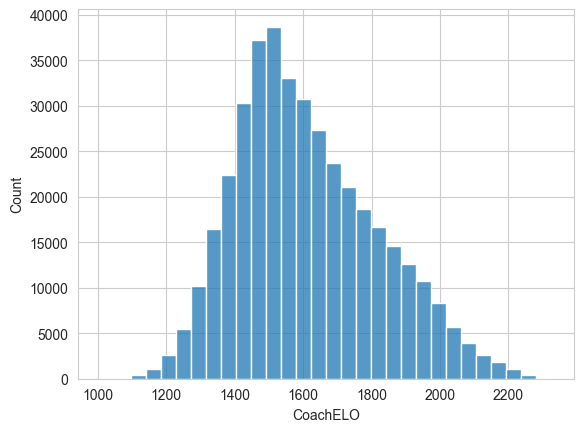

In [31]:
sns.histplot(elo_coach_df['CoachELO'], bins=30)

In [32]:
#best coaches in history ever
elo_coach_df.groupby('CoachName')['CoachELO'].max().sort_values(ascending=False).head(10)

CoachName
mark_few           2325.601307
tony_bennett       2309.966365
scott_drew         2293.638766
john_calipari      2292.641757
mike_krzyzewski    2273.233567
dan_hurley         2271.454154
bill_self          2269.661310
jay_wright         2266.502470
roy_williams       2262.627851
bo_ryan            2255.341448
Name: CoachELO, dtype: float64

In [33]:
elo_coach_df.sort_values(by='CoachELO', ascending=False).head(10)

,Season,DayNum,TeamID,CoachName,CoachELO
352620,2021,152,1211,mark_few,2325.601307
352614,2021,148,1211,mark_few,2320.353123
354156,2022,22,1211,mark_few,2317.756540
352602,2021,146,1211,mark_few,2314.596502
354042,2022,21,1211,mark_few,2311.807420
353696,2022,18,1211,mark_few,2310.982510
353316,2022,14,1211,mark_few,2310.620179
353146,2022,12,1211,mark_few,2310.447031
335856,2020,23,1438,tony_bennett,2309.966365
335568,2020,20,1438,tony_bennett,2309.861050


In [34]:
#take together elo for coaches and teams
elo_df = elo_df.merge(elo_coach_df, how='left', left_on=['Season', 'DayNum', 'TeamID'], right_on=['Season', 'DayNum', 'TeamID'])
elo_df

,Season,DayNum,TeamID,TeamELO,CoachName,CoachELO
0,1985,20,1228,1516.000000,lou_henson,1516.0
1,1985,20,1328,1484.000000,billy_tubbs,1484.0
2,1985,25,1106,1516.000000,james_oliver,1516.0
3,1985,25,1354,1484.000000,chico_caldwell,1484.0
4,1985,25,1112,1516.000000,lute_olson,1516.0
...,...,...,...,...,...,...
674351,2025,120,3408,1563.392865,NaN,NaN
674352,2025,120,3427,1783.314830,NaN,NaN
674353,2025,120,3187,1622.247486,NaN,NaN
674354,2025,120,3460,1341.104851,NaN,NaN


In [35]:
elo_df.to_csv(folder+'elo.csv', index=False)